In [1]:
# model configurations

class_names = ['Adenocarcinoma', 'Small Cell', 'Large Cell', 'Squamous Cell']
ct_model_path = 'ct_up_5/best.pt'
ct_test_data_path = 'ct_up_5/test_imgs'
ct_best_thresholds = [0.401, 0.245, 0.073, 0.300]


pet_classes = ['Adenocarcinoma', 'Small Cell', 'Squamous Cell']
pet_model_path = 'pet_base/best.pt'
pet_test_data_path = 'pet_base/test_imgs'
pet_best_thresholds = [0.485, 0.200, 0.194]

In [2]:
import torch

# detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f'Device selected: {device}')

Device selected: cuda


### CT Model

In [3]:
import torchvision.transforms as transforms

In [4]:
ct_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
import os
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image

In [6]:
# scan directory and extract labels
img_extensions = ('.png')

# check if directory exists
if not os.path.exists(ct_test_data_path):
    raise FileNotFoundError(f"CT test data directory not found: {ct_test_data_path}\n")

# mapping from first character to label
prefix_to_label = {'A': 0, 'B': 1, 'E': 2, 'G': 3}

test_img_paths = []
test_labels = []

for fname in os.listdir(ct_test_data_path):
    if fname.lower().endswith(img_extensions):

        # extract lung cancer class
        if fname.startswith('Lung-PET-CT-Dx-') and len(fname) > 15:
            prefix = fname[15].upper()
            if prefix in prefix_to_label:
                test_img_paths.append(os.path.join(ct_test_data_path, fname))
                test_labels.append(prefix_to_label[prefix])

if len(test_img_paths) == 0:
    raise ValueError(f"No test images found in {ct_test_data_path}\n")

print(f"Found {len(test_img_paths)} test images")
print(f"Label distribution: {dict(zip(['A','B','E','G'], [test_labels.count(i) for i in range(4)]))}")

class CTDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        image = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

test_dataset = CTDataset(test_img_paths, test_labels, transform=ct_transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

Found 6800 test images
Label distribution: {'A': 4864, 'B': 504, 'E': 56, 'G': 1376}


In [7]:
import json
import re
from pathlib import Path

In [8]:
# load test split from saved split file in model directory
model_dir = Path(ct_model_path).parent
split_files = sorted(model_dir.glob('split_seed*.json'))
if not split_files:
    raise FileNotFoundError(f"No split file found in {model_dir}")

split_path = split_files[-1]
with open(split_path, 'r') as f:
    split_info = json.load(f)

loaded_test_indices = split_info.get('test_indices', [])
if len(loaded_test_indices) == 0:
    raise ValueError('No test indices found in the split file.')

loaded_test_indices = set(int(x) for x in loaded_test_indices)
print(f"Loaded test sequences: {len(loaded_test_indices)}")

# get test images from directory using _seq<idx>_ in filename
test_img_dir = Path(ct_test_data_path)
if not test_img_dir.exists():
    raise FileNotFoundError(f"CT test image directory not found: {test_img_dir}")

seq_pattern = re.compile(r'_seq(\d+)_slice\d+\.png$', re.IGNORECASE)
prefix_to_label = {'A': 0, 'B': 1, 'E': 2, 'G': 3}
ct_class_names = ['Adenocarcinoma', 'Small Cell', 'Large Cell', 'Squamous Cell']

filtered_img_paths = []
filtered_labels = []
for p in sorted(test_img_dir.glob('*.png')):
    m = seq_pattern.search(p.name)
    if not m:
        continue
    seq_idx = int(m.group(1))
    if seq_idx not in loaded_test_indices:
        continue

    if p.name.startswith('Lung-PET-CT-Dx-') and len(p.name) > 15:
        prefix = p.name[15].upper()
    else:
        prefix = p.name[0].upper()

    if prefix in prefix_to_label:
        filtered_img_paths.append(str(p))
        filtered_labels.append(prefix_to_label[prefix])

if len(filtered_img_paths) == 0:
    raise ValueError('No PNG images matched test_indices from the split file.')

print(f"Matched test images from directory: {len(filtered_img_paths)}")
print(f"Label distribution: {dict(zip(['A','B','E','G'], [filtered_labels.count(i) for i in range(4)]))}")

Loaded test sequences: 850
Matched test images from directory: 6800
Label distribution: {'A': 4864, 'B': 504, 'E': 56, 'G': 1376}


In [9]:
import torch.nn as nn
import torchvision.models as models

In [10]:
# load CT model
ct_model = models.vgg16(pretrained=False)

num_classes = 4
ct_model.classifier[6] = nn.Linear(ct_model.classifier[6].in_features, num_classes)

ct_model = ct_model.to(device)

# load model weights
ct_checkpoint = torch.load(ct_model_path, map_location=device)
if 'model_state_dict' in ct_checkpoint:
    ct_model.load_state_dict(ct_checkpoint['model_state_dict'])
else:
    ct_model.load_state_dict(ct_checkpoint)
ct_model.eval()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

In [12]:
# accuracy, precision, recall, and f1 score
all_probs = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = ct_model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

if len(all_probs) == 0:
    raise ValueError("No predictions were made. The test loader might be empty.")

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)

# add best thresholds
refined_preds = []
for row in all_probs:
    pred = [row[i] > ct_best_thresholds[i] for i in range(len(ct_best_thresholds))]
    if sum(pred) == 1:
        refined_preds.append(np.argmax(pred))
    else:
        refined_preds.append(np.argmax(row))
refined_preds = np.array(refined_preds)

accuracy_thr = accuracy_score(all_labels, refined_preds)
precision_thr = precision_score(all_labels, refined_preds, average='weighted', zero_division=0)
recall_thr = recall_score(all_labels, refined_preds, average='weighted', zero_division=0)
f1_thr = f1_score(all_labels, refined_preds, average='weighted', zero_division=0)

print(f"\nAccuracy:  {accuracy_thr:.4f}")
print(f"Precision: {precision_thr:.4f}")
print(f"Recall:    {recall_thr:.4f}")
print(f"F1 Score:  {f1_thr:.4f}")


Accuracy:  0.8224
Precision: 0.8123
Recall:    0.8224
F1 Score:  0.8056


In [13]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

In [14]:
# calculate per-class metrics
precision_pc, recall_pc, f1_pc, _ = precision_recall_fscore_support(
    all_labels, refined_preds, labels=range(len(class_names)), zero_division=0
)

# calculate per-class accuracy from confusion matrix
cm_pc = confusion_matrix(all_labels, refined_preds, labels=range(len(class_names)))

# handle division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    accuracy_pc_ct = np.where(cm_pc.sum(axis=1) > 0, cm_pc.diagonal() / cm_pc.sum(axis=1), 0.0)

print("Per-Class Metrics")
print("=" * 70)
print(f"{'Class':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 70)
for i, name in enumerate(class_names):
    print(f"{name:<20} {accuracy_pc_ct[i]:<12.4f} {precision_pc[i]:<12.4f} {recall_pc[i]:<12.4f} {f1_pc[i]:<12.4f}")
print("=" * 70)

Per-Class Metrics
Class                Accuracy     Precision    Recall       F1 Score    
----------------------------------------------------------------------
Adenocarcinoma       0.9554       0.8443       0.9554       0.8964      
Small Cell           0.3155       0.7571       0.3155       0.4454      
Large Cell           0.3036       0.4250       0.3036       0.3542      
Squamous Cell        0.5589       0.7352       0.5589       0.6350      


In [15]:
import matplotlib.pyplot as plt

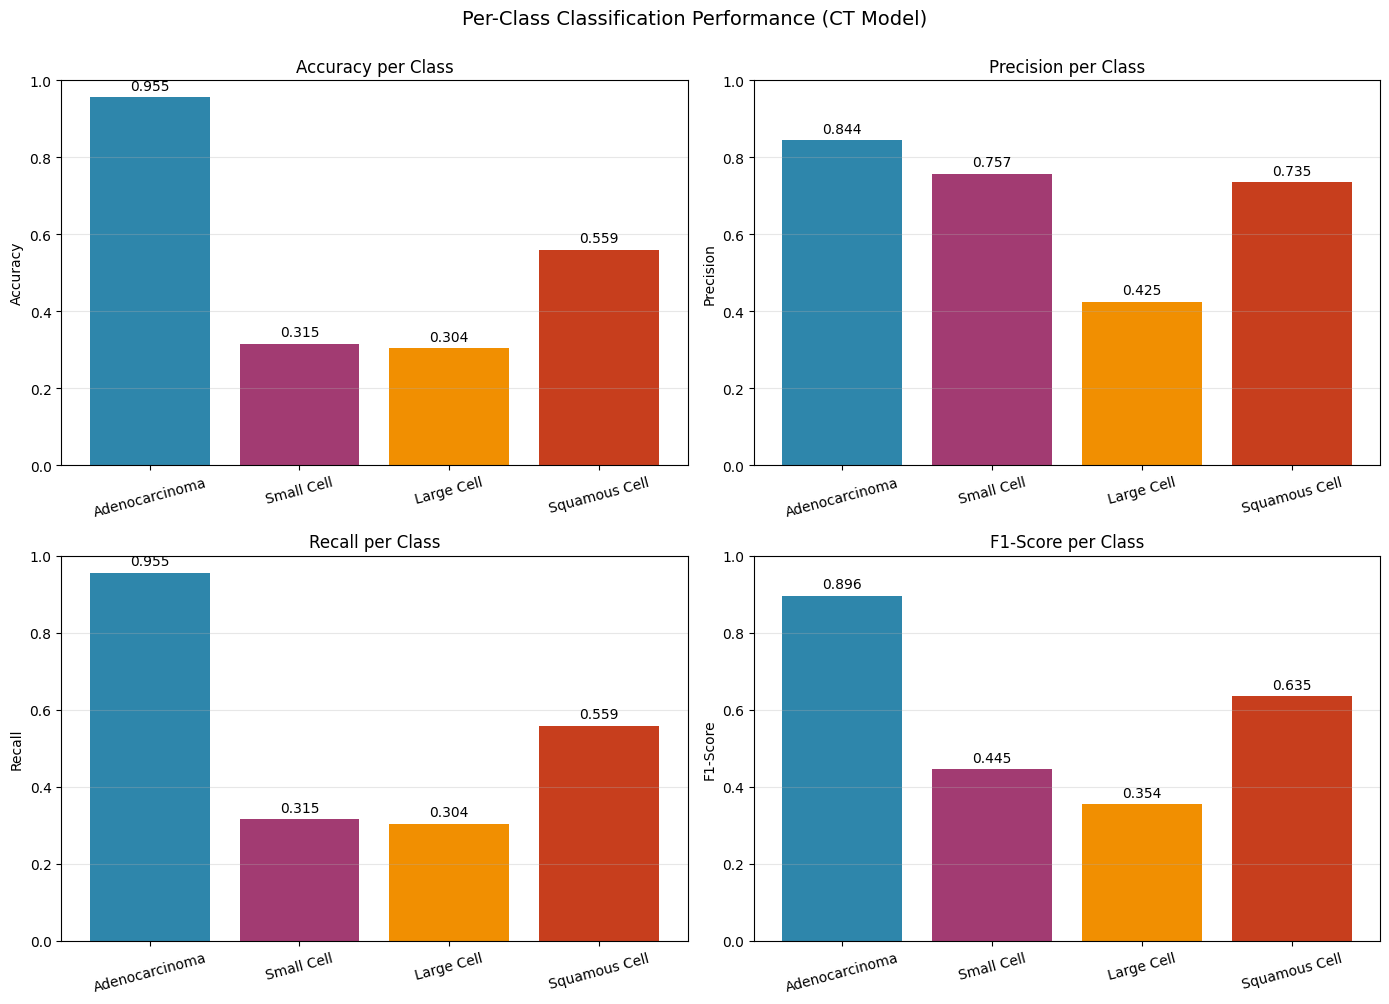

In [16]:
# plot per-class metrics
y_true = all_labels
y_pred = refined_preds

# calculate per-class metrics
class_accuracy_values = []
class_precision_values = []
class_recall_values = []
class_f1_values = []

for i, class_name in enumerate(class_names):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_prec = precision_score(y_true == i, y_pred == i, zero_division=0)
        class_rec = recall_score(y_true == i, y_pred == i, zero_division=0)
        class_f1 = f1_score(y_true == i, y_pred == i, zero_division=0)
    else:
        class_acc = 0.0
        class_prec = 0.0
        class_rec = 0.0
        class_f1 = 0.0
    
    class_accuracy_values.append(class_acc)
    class_precision_values.append(class_prec)
    class_recall_values.append(class_rec)
    class_f1_values.append(class_f1)

# color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# accuracy
axes[0, 0].bar(class_names, class_accuracy_values, color=colors)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy per Class')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracy_values):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 0].tick_params(axis='x', rotation=15)

# precision
axes[0, 1].bar(class_names, class_precision_values, color=colors)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision per Class')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_precision_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 1].tick_params(axis='x', rotation=15)

# recall
axes[1, 0].bar(class_names, class_recall_values, color=colors)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall per Class')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_recall_values):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 0].tick_params(axis='x', rotation=15)

# F1-Score
axes[1, 1].bar(class_names, class_f1_values, color=colors)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('F1-Score per Class')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_f1_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Per-Class Classification Performance (CT Model)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

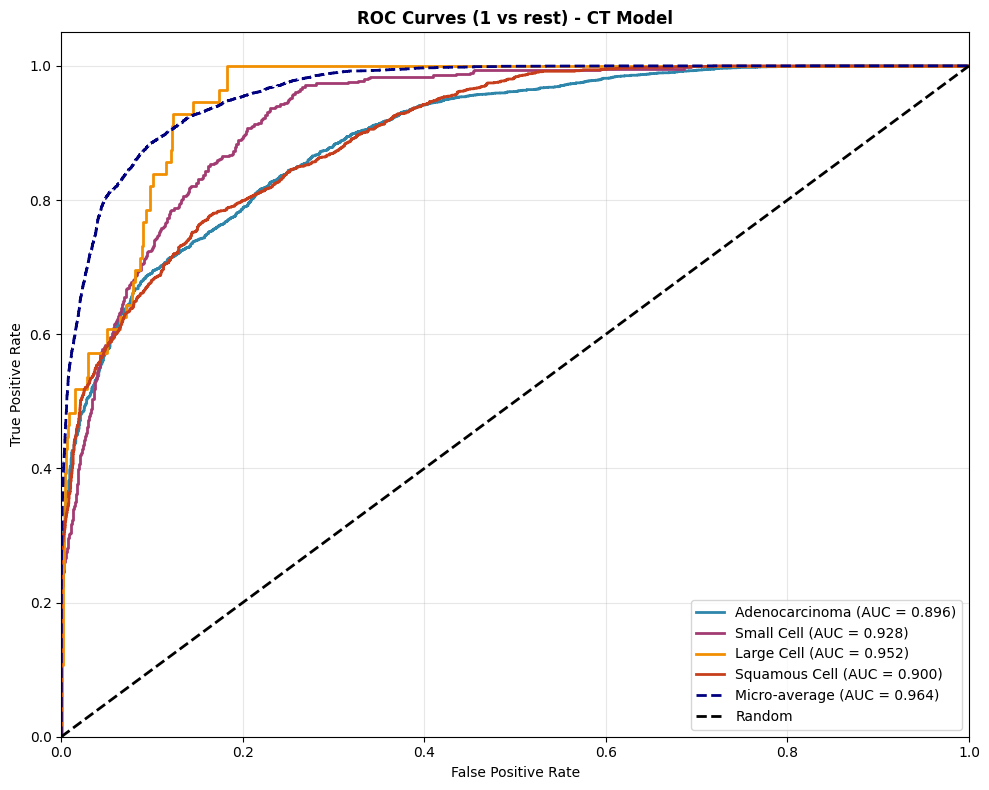


[ ] AUROC (Area Under ROC Curve) - CT Model

Adenocarcinoma: 0.8959
Small Cell: 0.9275
Large Cell: 0.9516
Squamous Cell: 0.9004

Macro-average AUROC: 0.9188
Micro-average AUROC: 0.9640


In [18]:
# prepare one-vs-rest targets and score matrix for CT
y_true_bin = label_binarize(all_labels, classes=np.arange(len(class_names)))
y_scores = all_probs

# plot AUROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

roc_auc = {}
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{class_name} (AUC = {roc_auc[class_name]:.3f})')

# micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color='navy', lw=2, linestyle='--',
        label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (1 vs rest) - CT Model', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AUC values
print('\n[ ] AUROC (Area Under ROC Curve) - CT Model\n')
for class_name in class_names:
    print(f'{class_name}: {roc_auc[class_name]:.4f}')
print(f'\nMacro-average AUROC: {np.mean(list(roc_auc.values())):.4f}')
print(f'Micro-average AUROC: {roc_auc_micro:.4f}')

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score

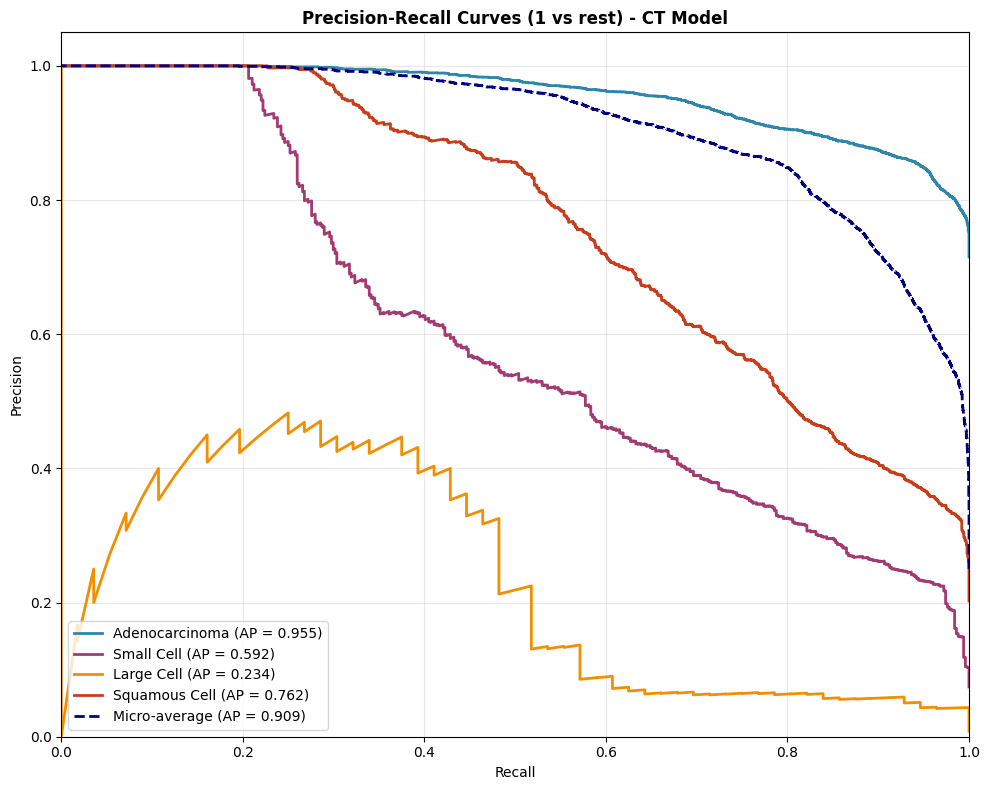


[ ] AUPRC (Area Under Precision-Recall Curve) - CT Model

Adenocarcinoma: 0.9552
Small Cell: 0.5916
Large Cell: 0.2338
Squamous Cell: 0.7617

Macro-average AUPRC: 0.6356
Micro-average AUPRC: 0.9094


In [20]:
# plot AUPRC (Precision-Recall) curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

pr_auc = {}
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc[class_name] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    ax.plot(recall, precision, color=color, lw=2,
            label=f'{class_name} (AP = {pr_auc[class_name]:.3f})')

# micro-average PR curve
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_scores.ravel())
pr_auc_micro = average_precision_score(y_true_bin, y_scores, average='micro')
ax.plot(recall_micro, precision_micro, color='navy', lw=2, linestyle='--',
        label=f'Micro-average (AP = {pr_auc_micro:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (1 vs rest) - CT Model', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AP values
print('\n[ ] AUPRC (Area Under Precision-Recall Curve) - CT Model\n')
for class_name in class_names:
    print(f'{class_name}: {pr_auc[class_name]:.4f}')
print(f'\nMacro-average AUPRC: {np.mean(list(pr_auc.values())):.4f}')
print(f'Micro-average AUPRC: {pr_auc_micro:.4f}')

In [21]:
import seaborn as sns

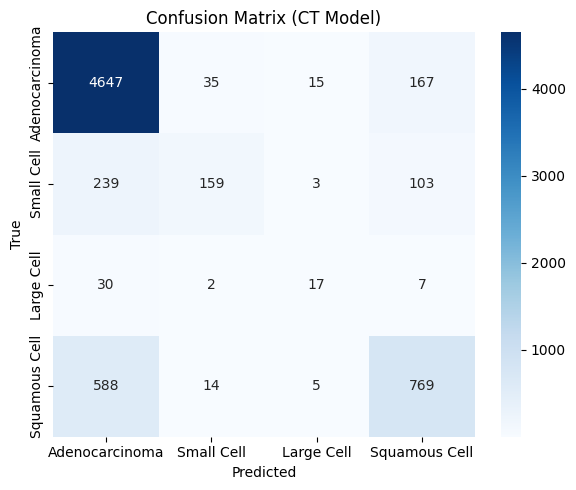

In [22]:
# confusion matrix
ct_class_names = class_names
cm = confusion_matrix(all_labels, refined_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ct_class_names, yticklabels=ct_class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (CT Model)')
plt.tight_layout()
plt.show()

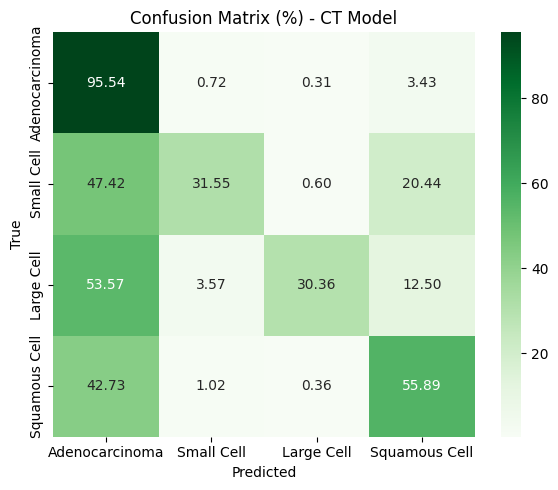

In [23]:
# normalize (row-wise)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Greens', xticklabels=ct_class_names, yticklabels=ct_class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (%) - CT Model')
plt.tight_layout()
plt.show()

### PET Model

In [24]:
from pathlib import Path

In [25]:
# test images
test_img_paths = sorted(list(Path(pet_test_data_path).glob('*.png')))
test_labels = []
for p in test_img_paths:
    
    # extract lung cancer class
    fname = p.name
    if fname.startswith('Lung-PET-CT-Dx-') and len(fname) > 15:
        prefix = fname[15].upper()
    else:
        prefix = fname[0].upper()
    
    if prefix == 'A':
        test_labels.append(0)
    elif prefix == 'B':
        test_labels.append(1)
    elif prefix == 'G':
        test_labels.append(2)
    else:
        test_labels.append(-1)

test_labels = np.array(test_labels)

class PETDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

In [26]:
# print PET test data distribution
unique_labels, counts = np.unique(test_labels, return_counts=True)
label_to_name = {0: pet_classes[0], 1: pet_classes[1], 2: pet_classes[2], -1: 'Unknown'}

print('[ ] PET test data distribution\n')
print(f'Total samples: {len(test_labels)}')
for label, count in sorted(zip(unique_labels, counts), key=lambda x: x[0]):
    class_name = label_to_name.get(int(label), f'Label {int(label)}')
    print(f'  {class_name}: {count}')

[ ] PET test data distribution

Total samples: 2840
  Adenocarcinoma: 2080
  Small Cell: 168
  Squamous Cell: 592


In [27]:
pet_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

pet_test_dataset = PETDataset(test_img_paths, test_labels, transform=pet_transform)
pet_test_loader = DataLoader(pet_test_dataset, batch_size=12, shuffle=False)

In [28]:
# load PET model
pet_model = models.vgg16(pretrained=False)
pet_model.classifier[6] = torch.nn.Linear(pet_model.classifier[6].in_features, len(pet_classes))

# load model weights
ckpt = torch.load(pet_model_path, map_location='cpu')
if 'model_state_dict' in ckpt:
    pet_model.load_state_dict(ckpt['model_state_dict'])
else:
    pet_model.load_state_dict(ckpt)
pet_model.eval()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [29]:
# inference
all_probs = []
all_labels = []
with torch.no_grad():
    for imgs, labels in pet_test_loader:
        outputs = pet_model(imgs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.numpy())
        all_labels.extend(labels.numpy())
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)

# add best thresholds
refined_preds = []
for row in all_probs:
    pred = [row[i] > pet_best_thresholds[i] for i in range(len(pet_best_thresholds))]
    if sum(pred) == 1:
        refined_preds.append(np.argmax(pred))
    else:
        refined_preds.append(np.argmax(row))
refined_preds = np.array(refined_preds)

# accuracy, precision, recall and f1-score
accuracy = accuracy_score(all_labels, refined_preds)
precision = precision_score(all_labels, refined_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, refined_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, refined_preds, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.8570
Precision: 0.8634
Recall:    0.8570
F1 Score:  0.8587


In [30]:
# calculate per-class metrics
precision_pc, recall_pc, f1_pc, _ = precision_recall_fscore_support(
all_labels, refined_preds, labels=range(len(pet_classes)), zero_division=0
)

# calculate per-class accuracy from confusion matrix
cm_pc = confusion_matrix(all_labels, refined_preds, labels=range(len(pet_classes)))

# handle division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    accuracy_pc_pet = np.where(cm_pc.sum(axis=1) > 0, cm_pc.diagonal() / cm_pc.sum(axis=1), 0.0)

print("Per-Class Metrics (PET Model):")
print("=" * 70)
print(f"{'Class':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 70)
for i, name in enumerate(pet_classes):
    print(f"{name:<20} {accuracy_pc_pet[i]:<12.4f} {precision_pc[i]:<12.4f} {recall_pc[i]:<12.4f} {f1_pc[i]:<12.4f}")
print("=" * 70)

Per-Class Metrics (PET Model):
Class                Accuracy     Precision    Recall       F1 Score    
----------------------------------------------------------------------
Adenocarcinoma       0.9163       0.9072       0.9163       0.9117      
Small Cell           0.6250       0.4688       0.6250       0.5357      
Squamous Cell        0.7145       0.8214       0.7145       0.7642      


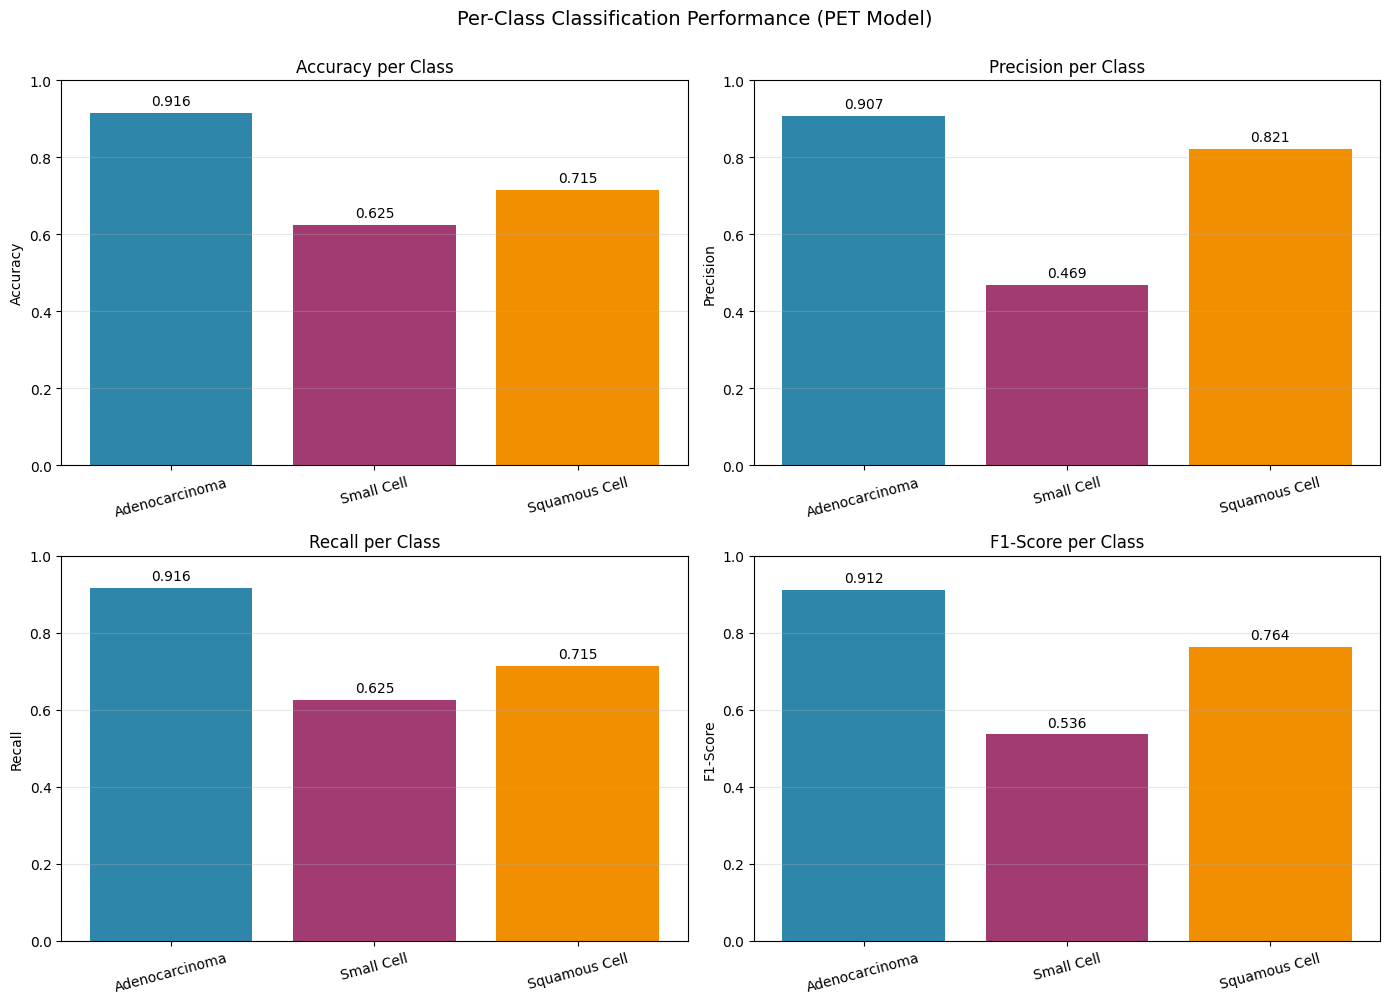

In [31]:
# plot per-class metrics
y_true = all_labels
y_pred = refined_preds

# calculate per-class metrics
class_accuracy_values = []
class_precision_values = []
class_recall_values = []
class_f1_values = []

for i, class_name in enumerate(pet_classes):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_prec = precision_score(y_true == i, y_pred == i, zero_division=0)
        class_rec = recall_score(y_true == i, y_pred == i, zero_division=0)
        class_f1 = f1_score(y_true == i, y_pred == i, zero_division=0)
    else:
        class_acc = 0.0
        class_prec = 0.0
        class_rec = 0.0
        class_f1 = 0.0
    
    class_accuracy_values.append(class_acc)
    class_precision_values.append(class_prec)
    class_recall_values.append(class_rec)
    class_f1_values.append(class_f1)

# color palette
colors = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# accuracy
axes[0, 0].bar(pet_classes, class_accuracy_values, color=colors)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy per Class')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracy_values):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 0].tick_params(axis='x', rotation=15)

# precision
axes[0, 1].bar(pet_classes, class_precision_values, color=colors)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision per Class')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_precision_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 1].tick_params(axis='x', rotation=15)

# recall
axes[1, 0].bar(pet_classes, class_recall_values, color=colors)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall per Class')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_recall_values):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 0].tick_params(axis='x', rotation=15)

# F1-Score
axes[1, 1].bar(pet_classes, class_f1_values, color=colors)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('F1-Score per Class')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_f1_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Per-Class Classification Performance (PET Model)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

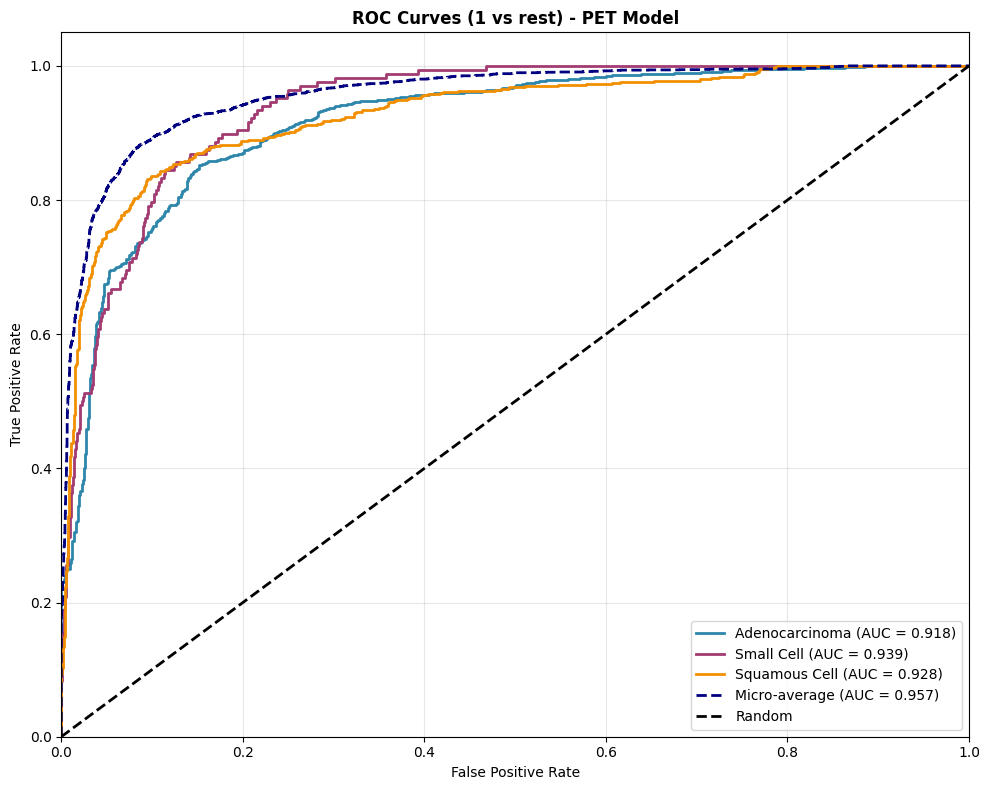


[ ] AUROC (Area Under ROC Curve) - PET Model

Adenocarcinoma: 0.9179
Small Cell: 0.9387
Squamous Cell: 0.9280

Macro-average AUROC: 0.9282
Micro-average AUROC: 0.9571


In [32]:
# prepare one-vs-rest targets and score matrix for PET
y_true_bin = label_binarize(all_labels, classes=np.arange(len(pet_classes)))
y_scores = all_probs

# plot AUROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

roc_auc = {}
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, (class_name, color) in enumerate(zip(pet_classes, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{class_name} (AUC = {roc_auc[class_name]:.3f})')

# micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color='navy', lw=2, linestyle='--',
        label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (1 vs rest) - PET Model', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AUC values
print('\n[ ] AUROC (Area Under ROC Curve) - PET Model\n')
for class_name in pet_classes:
    print(f'{class_name}: {roc_auc[class_name]:.4f}')
print(f'\nMacro-average AUROC: {np.mean(list(roc_auc.values())):.4f}')
print(f'Micro-average AUROC: {roc_auc_micro:.4f}')

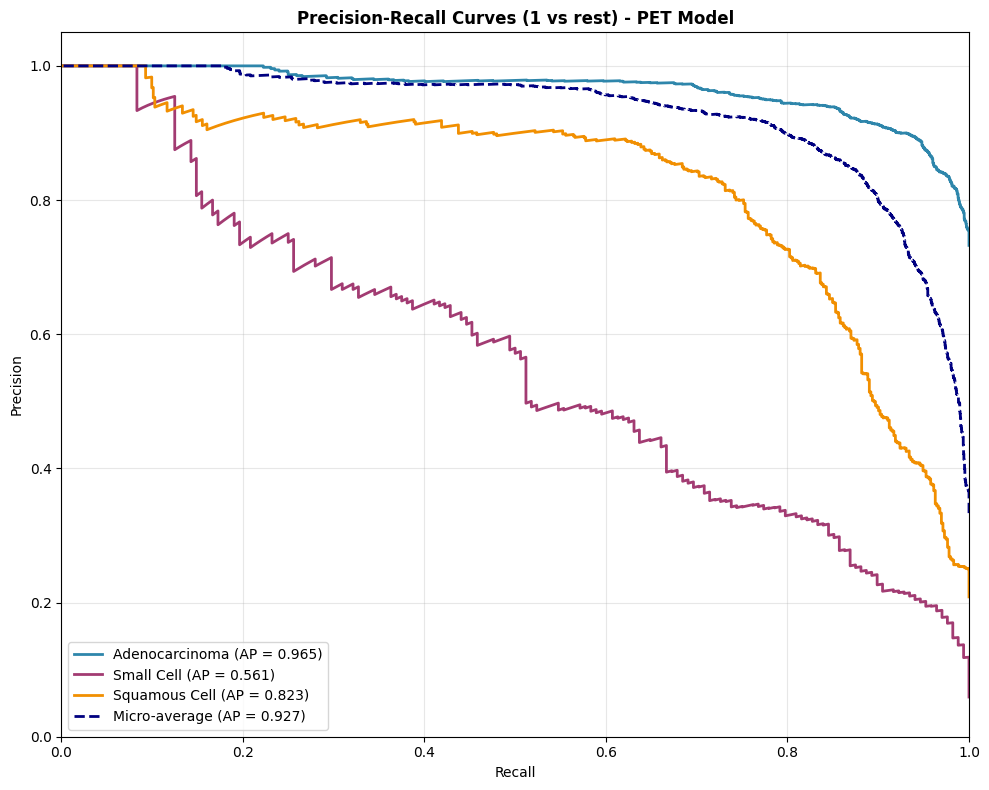


[ ] AUPRC (Area Under Precision-Recall Curve) - PET Model

Adenocarcinoma: 0.9654
Small Cell: 0.5611
Squamous Cell: 0.8229

Macro-average AUPRC: 0.7831
Micro-average AUPRC: 0.9274


In [33]:
# plot AUPRC (Precision-Recall) curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

pr_auc = {}
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, (class_name, color) in enumerate(zip(pet_classes, colors)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc[class_name] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    ax.plot(recall, precision, color=color, lw=2,
            label=f'{class_name} (AP = {pr_auc[class_name]:.3f})')

# micro-average PR curve
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_scores.ravel())
pr_auc_micro = average_precision_score(y_true_bin, y_scores, average='micro')
ax.plot(recall_micro, precision_micro, color='navy', lw=2, linestyle='--',
        label=f'Micro-average (AP = {pr_auc_micro:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (1 vs rest) - PET Model', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AP values
print('\n[ ] AUPRC (Area Under Precision-Recall Curve) - PET Model\n')
for class_name in pet_classes:
    print(f'{class_name}: {pr_auc[class_name]:.4f}')
print(f'\nMacro-average AUPRC: {np.mean(list(pr_auc.values())):.4f}')
print(f'Micro-average AUPRC: {pr_auc_micro:.4f}')

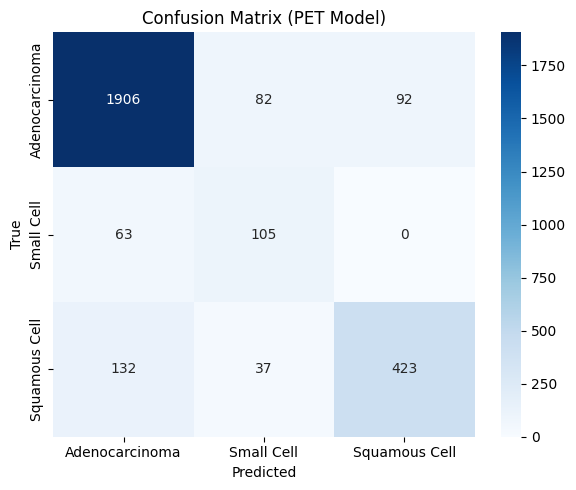

In [34]:
# confusion matrix
cm = confusion_matrix(all_labels, refined_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pet_classes, yticklabels=pet_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (PET Model)')
plt.tight_layout()
plt.show()

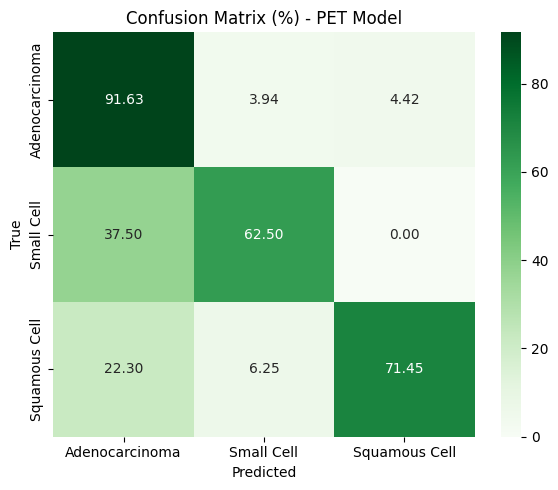

In [35]:
# normalize (row-wise)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_percent, annot=True, fmt='.2f', cmap='Greens', xticklabels=pet_classes, yticklabels=pet_classes
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (%) - PET Model')
plt.tight_layout()
plt.show()

### Anatomical-Functional Fusion

In [36]:
import gc
import re
import shutil
import random

random.seed(42)

In [37]:
# data paths
dual_dir = Path('dual-images')
dual_dir.mkdir(exist_ok=True)

# extract patient id
pat_id_re = re.compile(r'([ABEG]\d{4,})', re.IGNORECASE)
def extract_patient_id(fname):
    m = pat_id_re.search(fname)
    return m.group(1) if m else None

def get_patient_files(img_dir):
    files = list(img_dir.glob('*.png'))
    pat_map = {}
    for f in files:
        pid = extract_patient_id(f.name)
        if pid:
            pat_map.setdefault(pid, []).append(f)
    return pat_map

ct_pat_map = get_patient_files(Path(ct_test_data_path))
pet_pat_map = get_patient_files(Path(pet_test_data_path))

# group PET/CT
del_files = []
count = 0
for pid, ct_files in ct_pat_map.items():
    pet_files = pet_pat_map.get(pid, [])

    # handle Large Cell Carcinoma (E) as CT-only when PET is unavailable
    is_large_cell = pid[0].upper() == 'E'
    if not pet_files and not is_large_cell:
        continue

    # rename pairs
    n_pairs = min(len(ct_files), len(pet_files)) if not is_large_cell else len(ct_files)
    for i in range(n_pairs):
        group_name = f'{pid}_{i+1}'
        group_dir = dual_dir / group_name
        group_dir.mkdir(exist_ok=True)
        shutil.copy(ct_files[i], group_dir / f'ct_{ct_files[i].name}')
        if i < len(pet_files):
            shutil.copy(pet_files[i], group_dir / f'pet_{pet_files[i].name}')
        count += 1
print(f'Created {count} dual-image groups.')


# free memory
del ct_pat_map, pet_pat_map
plt.close('all')
gc.collect()

Created 2024 dual-image groups.


0

In [38]:
# load dual image pairs (include groups with only CT or only PET)
def get_dual_image_pairs(dual_dir):
    pairs = []
    for group_dir in Path(dual_dir).iterdir():
        if group_dir.is_dir():
            ct_img = None
            pet_img = None
            for img_path in group_dir.glob('*.png'):
                if img_path.name.startswith('ct_'):
                    ct_img = img_path
                elif img_path.name.startswith('pet_'):
                    pet_img = img_path
            if ct_img is not None or pet_img is not None:
                pairs.append((ct_img, pet_img))
    return pairs

def get_prefix_from_name(name):
    if name.startswith('ct_') or name.startswith('pet_'):
        name = name[3:]
    if name.startswith('Lung-PET-CT-Dx-') and len(name) > 15:
        return name[15].upper()
    return name[0].upper()

dual_dir = 'dual-images'
dual_pairs = get_dual_image_pairs(dual_dir)

ct_only = sum(1 for ct, pet in dual_pairs if ct is not None and pet is None)
pet_only = sum(1 for ct, pet in dual_pairs if ct is None and pet is not None)
both = sum(1 for ct, pet in dual_pairs if ct is not None and pet is not None)

# Large Cell Carcinoma (E)
large_cell_ct_only = sum(
    1
    for ct, pet in dual_pairs
    if ct is not None and pet is None and get_prefix_from_name(ct.name) == 'E'
)

print(f'Dual-images: {both}')
print(f'Large Cell Carcinoma (CT only): {large_cell_ct_only}')


Dual-images: 1968
Large Cell Carcinoma (CT only): 56


In [39]:
from collections import Counter

In [40]:
# per-class image count in dual-image split
label_map = {'A': 0, 'B': 1, 'E': 2, 'G': 3}

class_counts = Counter()
for ct_img_path, _ in dual_pairs:

    # handle both "ct_Lung-PET-CT-Dx-A0184..." and older formats
    fname = ct_img_path.name
    if fname.startswith('ct_'):
        fname = fname[3:]  # remove "ct_" prefix
    
    # extract class letter from "Lung-PET-CT-Dx-{CLASS}..."
    if fname.startswith('Lung-PET-CT-Dx-') and len(fname) > 15:
        prefix = fname[15].upper()
    else:
        prefix = fname[0].upper()
    
    class_idx = label_map.get(prefix, -1)
    if class_idx != -1:
        class_counts[class_idx] += 1
        
print("[ ] Per-class image count:\n")
for idx, name in enumerate(ct_class_names):
    print(f"  {name}: {class_counts[idx]}")

[ ] Per-class image count:

  Adenocarcinoma: 1488
  Small Cell: 40
  Large Cell: 56
  Squamous Cell: 440


In [41]:
ensemble_labels = []
ensemble_preds = []
ensemble_probs_list = []

pet_model_cpu = pet_model.to('cpu')


def extract_label_and_prefix(img_path, prefix_strip):
    """Extract class prefix and label from a filename, stripping a leading prefix."""
    fname = img_path.name
    if fname.startswith(prefix_strip):
        fname = fname[len(prefix_strip):]

    if fname.startswith('Lung-PET-CT-Dx-') and len(fname) > 15:
        prefix = fname[15].upper()
        
    return prefix, label_map.get(prefix, -1)

for ct_img_path, pet_img_path in dual_pairs:

    # extract true label (prefer CT filename, fall back to PET)
    if ct_img_path is not None:
        prefix, true_label = extract_label_and_prefix(ct_img_path, 'ct_')
    else:
        prefix, true_label = extract_label_and_prefix(pet_img_path, 'pet_')
    ensemble_labels.append(true_label)

    ct_prob = None
    pet_prob = None

    # CT prediction
    if ct_img_path is not None:
        ct_img = Image.open(ct_img_path).convert('RGB')
        ct_tensor = ct_transform(ct_img).unsqueeze(0).to(device)
        with torch.no_grad():
            ct_out = ct_model(ct_tensor)
            ct_prob = torch.softmax(ct_out, dim=1).cpu().numpy()[0]

    # PET prediction
    if pet_img_path is not None:
        pet_img = Image.open(pet_img_path).convert('RGB')
        pet_tensor = pet_transform(pet_img).unsqueeze(0).to('cpu')

        with torch.no_grad():
            pet_out = pet_model_cpu(pet_tensor)
            pet_prob = torch.softmax(pet_out, dim=1).cpu().numpy()[0]

    # ensemble decision
    if ct_prob is not None and pet_prob is not None:

        # both modalities available
        ct_pred_mask = [ct_prob[i] > ct_best_thresholds[i] for i in range(4)]
        pet_pred_mask = [pet_prob[i] > pet_best_thresholds[i] for i in range(3)]

        ct_pred = np.argmax(ct_pred_mask) if sum(ct_pred_mask) == 1 else np.argmax(ct_prob)
        pet_pred = np.argmax(pet_pred_mask) if sum(pet_pred_mask) == 1 else np.argmax(pet_prob)

        ensemble_pred = 3 if ct_pred == 3 else (pet_pred if pet_pred in [0, 1, 2] else ct_pred)

        # map PET 3-class probs to 4-class: [A, B, E=0, G]
        pet_prob_4 = np.array([pet_prob[0], pet_prob[1], 0.0, pet_prob[2]])
        ensemble_prob = (ct_prob + pet_prob_4) / 2.0

    elif ct_prob is not None:

        # CT only
        ct_pred_mask = [ct_prob[i] > ct_best_thresholds[i] for i in range(4)]
        ensemble_pred = np.argmax(ct_pred_mask) if sum(ct_pred_mask) == 1 else np.argmax(ct_prob)
        ensemble_prob = ct_prob.copy()

    else:

        # PET only (E: assign 0 prob)
        pet_pred_mask = [pet_prob[i] > pet_best_thresholds[i] for i in range(3)]
        pet_pred = np.argmax(pet_pred_mask) if sum(pet_pred_mask) == 1 else np.argmax(pet_prob)

        # map PET class indices: 0→A, 1→B, 2→G
        pet_to_global = {0: 0, 1: 1, 2: 3}
        ensemble_pred = pet_to_global.get(int(pet_pred), int(pet_pred))
        ensemble_prob = np.array([pet_prob[0], pet_prob[1], 0.0, pet_prob[2]])

    ensemble_preds.append(ensemble_pred)
    ensemble_probs_list.append(ensemble_prob)

ensemble_labels = np.array(ensemble_labels)
ensemble_preds = np.array(ensemble_preds)
ensemble_probs = np.array(ensemble_probs_list)

In [42]:
# overall ensemble metrics
accuracy_ens = accuracy_score(ensemble_labels, ensemble_preds)
precision_ens = precision_score(ensemble_labels, ensemble_preds, average='weighted', zero_division=0)
recall_ens = recall_score(ensemble_labels, ensemble_preds, average='weighted', zero_division=0)
f1_ens = f1_score(ensemble_labels, ensemble_preds, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy_ens:.4f}")
print(f"Precision: {precision_ens:.4f}")
print(f"Recall:    {recall_ens:.4f}")
print(f"F1 Score:  {f1_ens:.4f}")

Accuracy:  0.7871
Precision: 0.8575
Recall:    0.7871
F1 Score:  0.8172


In [43]:
# calculate per-class metrics
precision_pc, recall_pc, f1_pc, _ = precision_recall_fscore_support(
    ensemble_labels, ensemble_preds, labels=range(len(class_names)), zero_division=0
)

# calculate per-class accuracy from confusion matrix
cm = confusion_matrix(ensemble_labels, ensemble_preds, labels=range(len(class_names)))

# handle division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    accuracy_pc = np.where(cm.sum(axis=1) > 0, cm.diagonal() / cm.sum(axis=1), 0.0)

print("Per-Class Metrics:")
print("=" * 70)
print(f"{'Class':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 70)
for i, name in enumerate(class_names):
    print(f"{name:<20} {accuracy_pc[i]:<12.4f} {precision_pc[i]:<12.4f} {recall_pc[i]:<12.4f} {f1_pc[i]:<12.4f}")
print("=" * 70)

Per-Class Metrics:
Class                Accuracy     Precision    Recall       F1 Score    
----------------------------------------------------------------------
Adenocarcinoma       0.8716       0.9385       0.8716       0.9038      
Small Cell           0.4000       0.1905       0.4000       0.2581      
Large Cell           0.3036       0.0833       0.3036       0.1308      
Squamous Cell        0.5977       0.7429       0.5977       0.6625      


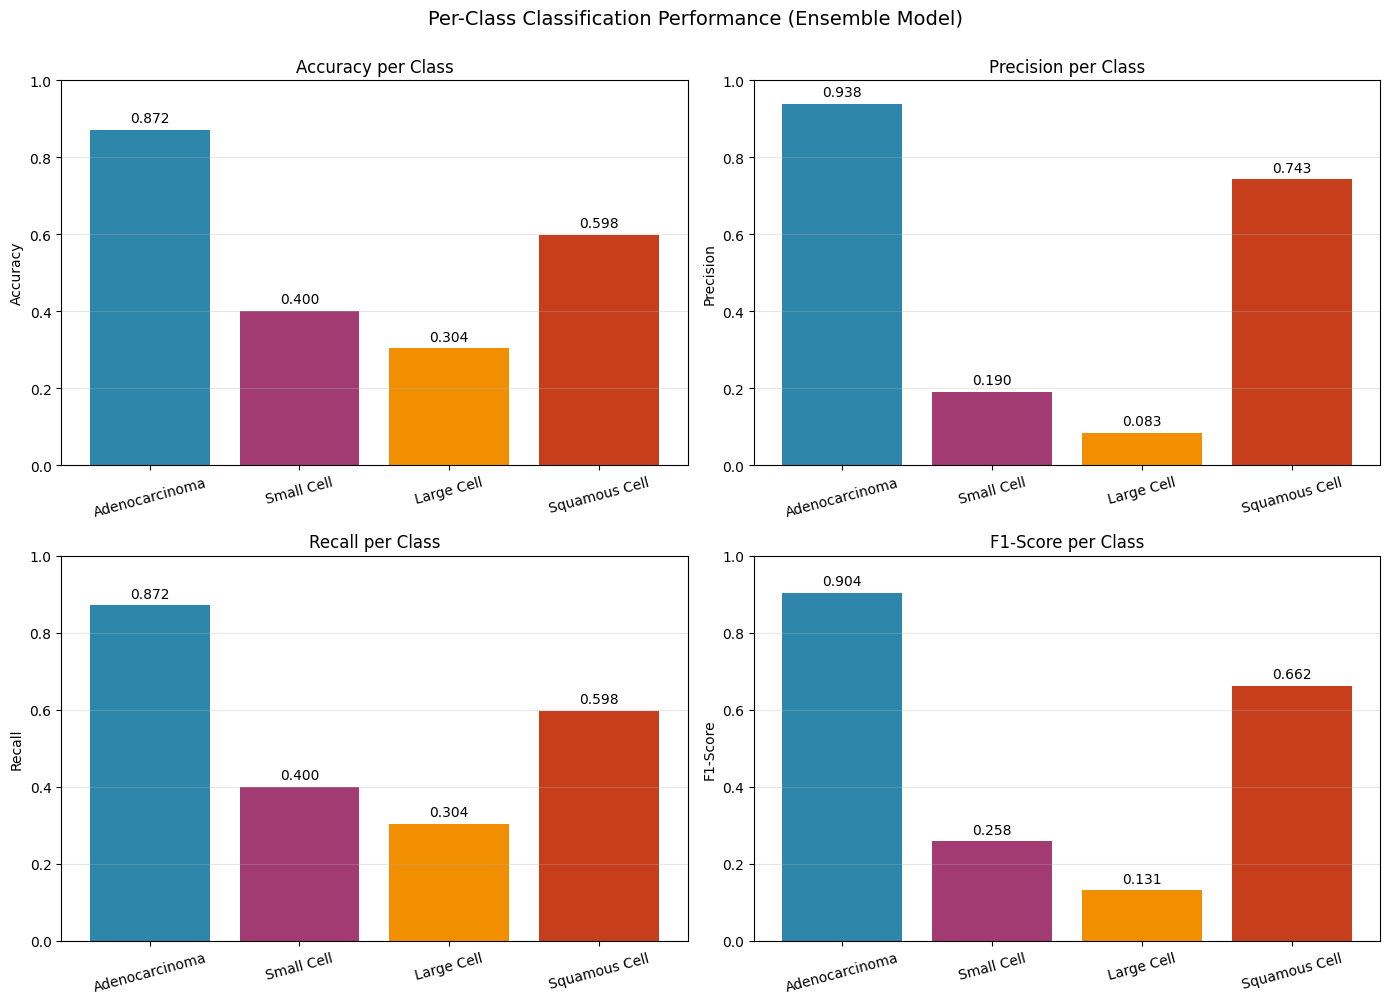

In [44]:
# plot per-class metrics
y_true = ensemble_labels
y_pred = ensemble_preds

# calculate per-class metrics
class_accuracy_values = []
class_precision_values = []
class_recall_values = []
class_f1_values = []

for i, class_name in enumerate(class_names):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_prec = precision_score(y_true == i, y_pred == i, zero_division=0)
        class_rec = recall_score(y_true == i, y_pred == i, zero_division=0)
        class_f1 = f1_score(y_true == i, y_pred == i, zero_division=0)
    else:
        class_acc = 0.0
        class_prec = 0.0
        class_rec = 0.0
        class_f1 = 0.0
    
    class_accuracy_values.append(class_acc)
    class_precision_values.append(class_prec)
    class_recall_values.append(class_rec)
    class_f1_values.append(class_f1)

# color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# accuracy
axes[0, 0].bar(class_names, class_accuracy_values, color=colors)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy per Class')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracy_values):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 0].tick_params(axis='x', rotation=15)

# precision
axes[0, 1].bar(class_names, class_precision_values, color=colors)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision per Class')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_precision_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 1].tick_params(axis='x', rotation=15)

# recall
axes[1, 0].bar(class_names, class_recall_values, color=colors)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall per Class')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_recall_values):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 0].tick_params(axis='x', rotation=15)

# F1-Score
axes[1, 1].bar(class_names, class_f1_values, color=colors)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('F1-Score per Class')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_f1_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Per-Class Classification Performance (Ensemble Model)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

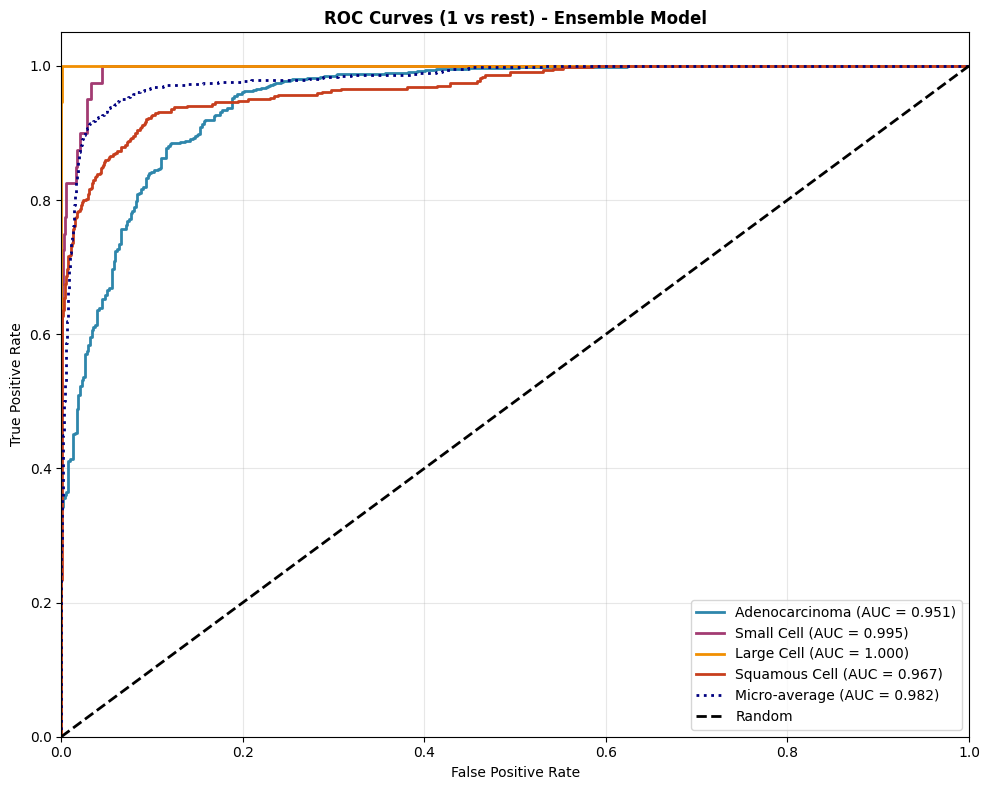


[ ] AUROC (Area Under ROC Curve) - Ensemble Model

Adenocarcinoma: 0.9507
Small Cell: 0.9947
Large Cell: 1.0000
Squamous Cell: 0.9667

Macro-average AUROC: 0.9780
Micro-average AUROC: 0.9818


In [45]:
# prepare one-vs-rest targets and score matrix for ensemble
y_true_bin = label_binarize(ensemble_labels, classes=np.arange(len(class_names)))
y_scores = ensemble_probs

# plot AUROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

roc_auc = {}
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{class_name} (AUC = {roc_auc[class_name]:.3f})')

# Micro-average AUROC
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color='navy', lw=2, linestyle=':',
        label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (1 vs rest) - Ensemble Model', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AUC values
print('\n[ ] AUROC (Area Under ROC Curve) - Ensemble Model\n')
for class_name in class_names:
    print(f'{class_name}: {roc_auc[class_name]:.4f}')
print(f'\nMacro-average AUROC: {np.mean(list(roc_auc.values())):.4f}')
print(f'Micro-average AUROC: {roc_auc_micro:.4f}')


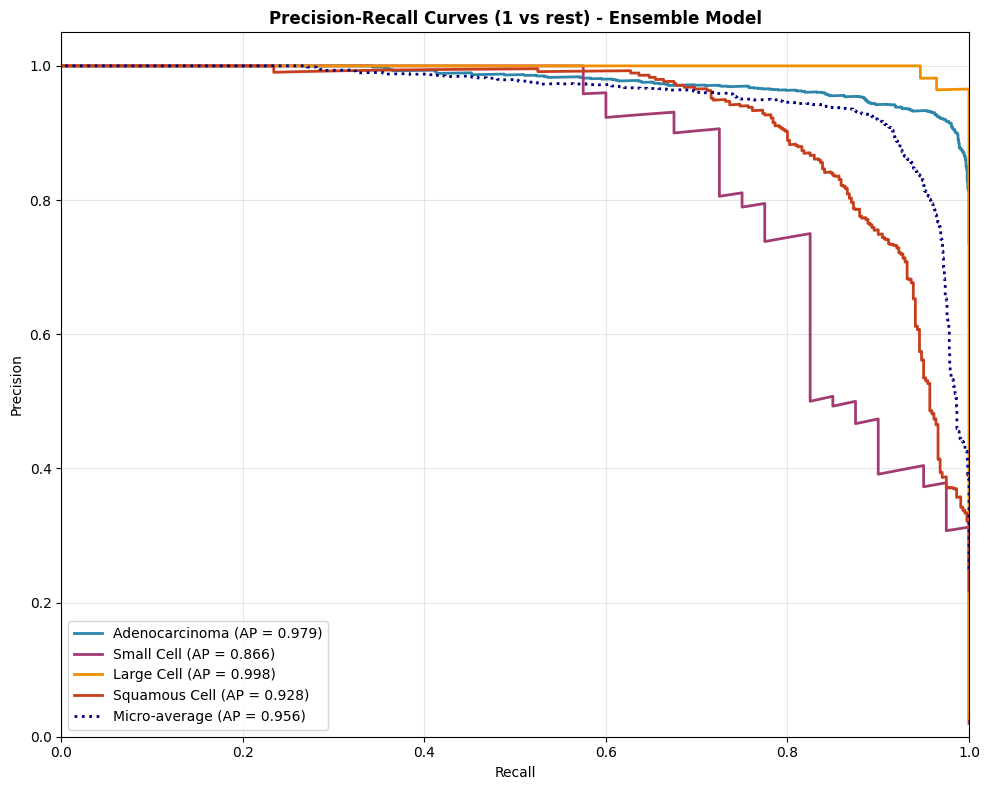


[ ] AUPRC (Area Under Precision-Recall Curve) - Ensemble Model

Adenocarcinoma: 0.9791
Small Cell: 0.8657
Large Cell: 0.9984
Squamous Cell: 0.9279

Macro-average AUPRC: 0.9428
Micro-average AUPRC: 0.9558


In [46]:
# plot AUPRC (Precision-Recall) curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

pr_auc = {}
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc[class_name] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    ax.plot(recall, precision, color=color, lw=2,
            label=f'{class_name} (AP = {pr_auc[class_name]:.3f})')

# Micro-average AUPRC
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_scores.ravel())
pr_auc_micro = average_precision_score(y_true_bin, y_scores, average='micro')
ax.plot(recall_micro, precision_micro, color='navy', lw=2, linestyle=':',
        label=f'Micro-average (AP = {pr_auc_micro:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (1 vs rest) - Ensemble Model', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AP values
print('\n[ ] AUPRC (Area Under Precision-Recall Curve) - Ensemble Model\n')
for class_name in class_names:
    print(f'{class_name}: {pr_auc[class_name]:.4f}')
print(f'\nMacro-average AUPRC: {np.mean(list(pr_auc.values())):.4f}')
print(f'Micro-average AUPRC: {pr_auc_micro:.4f}')

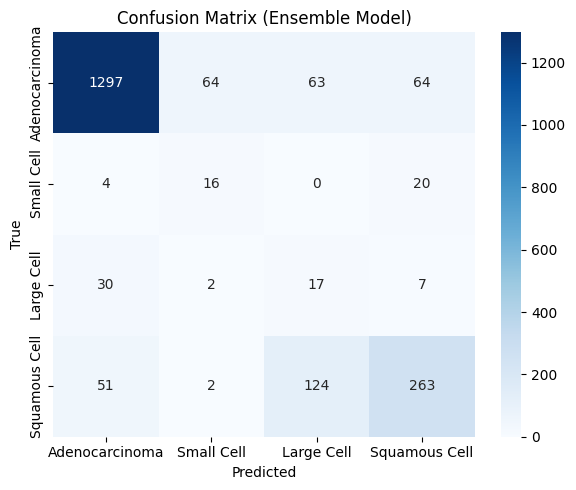

In [47]:
# plot confusion matrix
cm = confusion_matrix(ensemble_labels, ensemble_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Ensemble Model)')
plt.tight_layout()
plt.show()

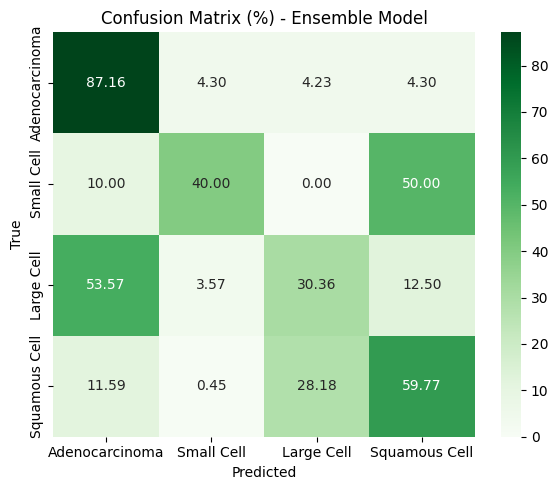

In [48]:
# normalize (row-wise)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))
sns.heatmap( cm_percent, annot=True, fmt='.2f', cmap='Greens', xticklabels=ct_class_names, yticklabels=ct_class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (%) - Ensemble Model')
plt.tight_layout()
plt.show()

In [49]:
#  accuracy on A/B/G test samples
abg_global = [0, 1, 3]

# filter only A/B/G ground-truth samples from the test set
abg_mask = np.isin(ensemble_labels, abg_global)
if not np.any(abg_mask):
    raise ValueError('No A/B/G samples found in ensemble_labels.')

y_true_abg = ensemble_labels[abg_mask]
y_pred_abg = ensemble_preds[abg_mask]

correct = int(np.sum(y_true_abg == y_pred_abg))
total = int(len(y_true_abg))
accuracy = correct / total

print('[ ] Final Accuracy On Test Samples (A, B , G):\n')
print(f'Accurate samples: {correct}/{total}')
print(f'Accuracy: {accuracy * 100:.2f}%')

[ ] Final Accuracy On Test Samples (A, B , G):

Accurate samples: 1576/1968
Accuracy: 80.08%
